# Task 1: Diagnostic Enhancement of Chest X-Rays

**Goal:** Take severely underexposed chest X-rays and mathematically process them
so lung cavities and fluid build-up become visible, before handing them to
diagnostic doctors.

Pipeline: Load -> Histogram Equalization -> Color Mapping -> Color Balance ->
Thresholding -> Log Transform -> Gamma (Power-Law) Transform.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)

def show(img, title, cmap='gray'):
    plt.figure(figsize=(5, 5))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


## 1. Load and Display
Load the raw, underexposed grayscale X-ray.

Shape: (232, 232) | dtype: uint8 | min/max: 0 255


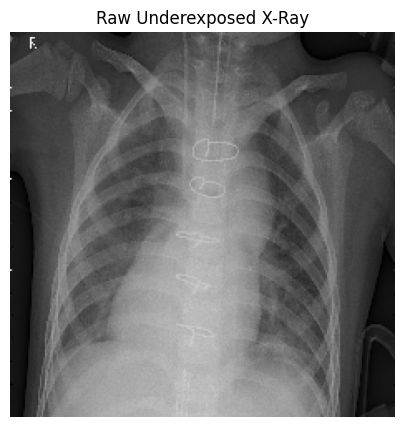

True

In [2]:
raw = cv2.imread('data/sample_xray.png', cv2.IMREAD_GRAYSCALE)
print('Shape:', raw.shape, '| dtype:', raw.dtype, '| min/max:', raw.min(), raw.max())
show(raw, 'Raw Underexposed X-Ray')
cv2.imwrite('output/01_raw.png', raw)


## 2. Contrast Enhancement (Histogram Equalization)
Forcefully redistributes pixel intensities across the full 0-255 range so
lung structures that were compressed into a narrow dark band become visible.

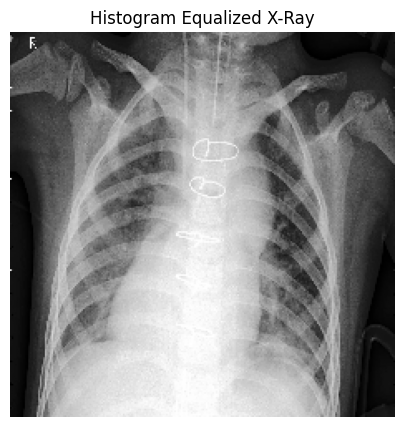

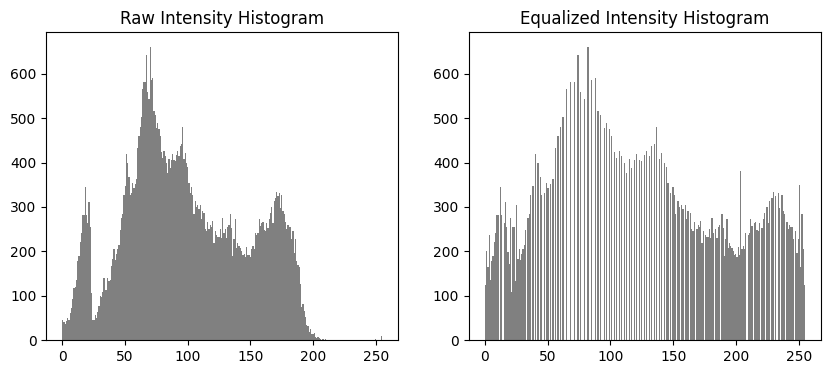

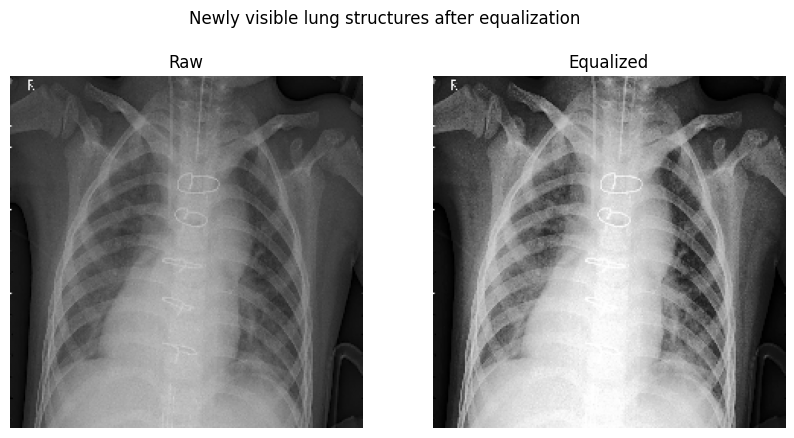

In [3]:
equalized = cv2.equalizeHist(raw)
show(equalized, 'Histogram Equalized X-Ray')
cv2.imwrite('output/02_equalized.png', equalized)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(raw.ravel(), bins=256, range=(0, 255), color='gray')
ax[0].set_title('Raw Intensity Histogram')
ax[1].hist(equalized.ravel(), bins=256, range=(0, 255), color='gray')
ax[1].set_title('Equalized Intensity Histogram')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(raw, cmap='gray'); ax[0].set_title('Raw'); ax[0].axis('off')
ax[1].imshow(equalized, cmap='gray'); ax[1].set_title('Equalized'); ax[1].axis('off')
plt.suptitle('Newly visible lung structures after equalization')
plt.show()


**Observation:** the raw histogram is crushed into a narrow low-intensity
band (severe underexposure). After equalization the histogram spreads across
the full range, and the rib boundaries / lung field edges that were
invisible in the raw image become distinguishable.

## 3. Color Mapping
Convert the equalized grayscale image into a false-color heatmap
(`COLORMAP_JET`). Mapping intensity to a color spectrum helps the human eye
pick up subtle fluid boundaries that are hard to see in pure grayscale.

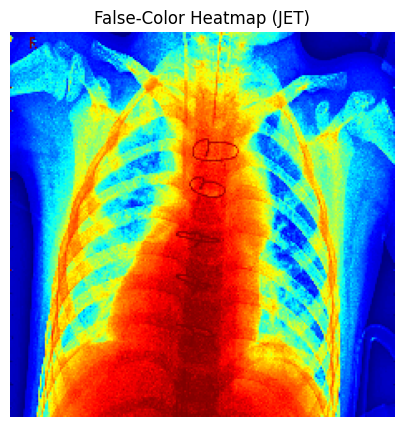

True

In [4]:
heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)
show(heatmap, 'False-Color Heatmap (JET)')
cv2.imwrite('output/03_heatmap.png', heatmap)


## 4. Color Balance
Simulate a lighting correction: shift each channel so the mean is
neutralized, removing artificial color casts introduced by the colormap.

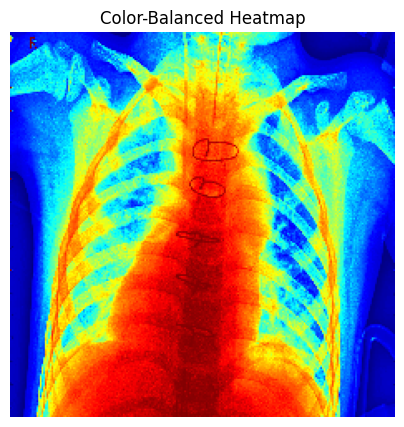

True

In [5]:
def color_balance(img):
    result = img.copy().astype(np.float32)
    for c in range(3):
        mean = result[:, :, c].mean()
        # push each channel mean toward the overall gray mean (128)
        result[:, :, c] += (128 - mean) * 0.3
    return np.clip(result, 0, 255).astype(np.uint8)

balanced = color_balance(heatmap)
show(balanced, 'Color-Balanced Heatmap')
cv2.imwrite('output/04_color_balanced.png', balanced)


## 5. Color Filtering (Thresholding)
Dense tissue (bone / dense fluid) reflects high-intensity values. Apply a
strict binary threshold to mask out everything except the densest tissue.

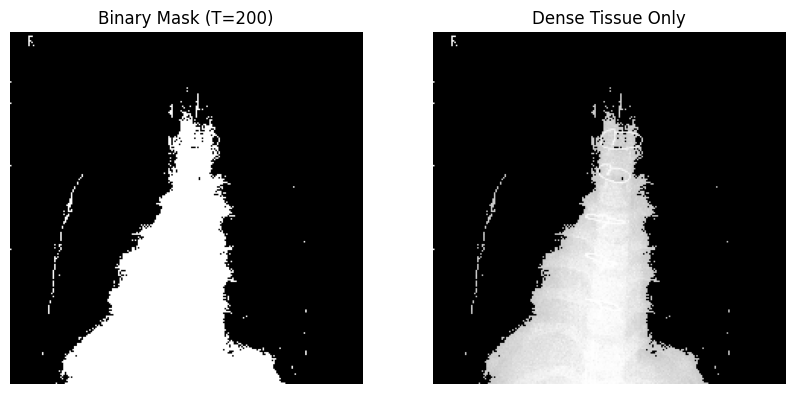

True

In [6]:
THRESH = 200  # tune based on your dataset's dense-tissue intensity
_, dense_mask = cv2.threshold(equalized, THRESH, 255, cv2.THRESH_BINARY)
dense_tissue_only = cv2.bitwise_and(equalized, equalized, mask=dense_mask)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(dense_mask, cmap='gray'); ax[0].set_title(f'Binary Mask (T={THRESH})'); ax[0].axis('off')
ax[1].imshow(dense_tissue_only, cmap='gray'); ax[1].set_title('Dense Tissue Only'); ax[1].axis('off')
plt.show()
cv2.imwrite('output/05_dense_mask.png', dense_mask)
cv2.imwrite('output/05_dense_tissue_only.png', dense_tissue_only)


## 6. Logarithmic Transformation
Applied to the *raw* underexposed image. Expands the dark background
regions to reveal faint outer edges of the ribcage that are otherwise lost
near zero intensity.

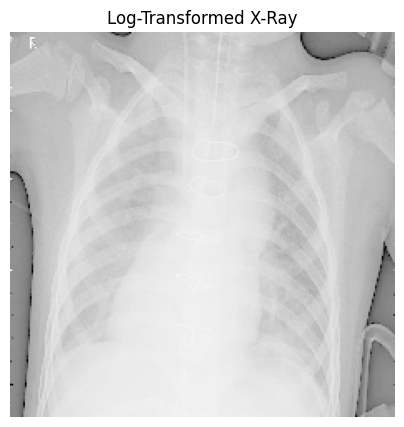

True

In [7]:
raw_f = raw.astype(np.float32)
c = 255 / np.log(1 + raw_f.max())
log_transformed = c * np.log(1 + raw_f)
log_transformed = np.clip(log_transformed, 0, 255).astype(np.uint8)

show(log_transformed, 'Log-Transformed X-Ray')
cv2.imwrite('output/06_log_transformed.png', log_transformed)


## 7. Power-Law (Gamma) Transformation
Apply a fractional gamma (< 1.0) to compress the harsh contrast of bright
bone regions, so mid-tone soft-tissue detail becomes clearer without
blowing out highlights.

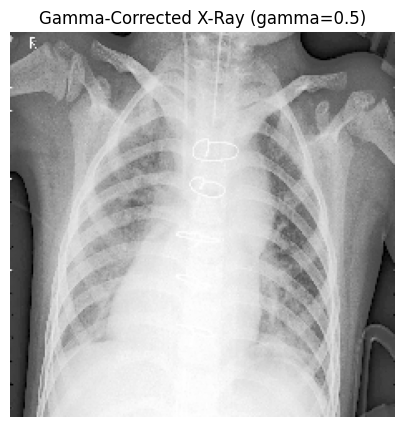

True

In [8]:
GAMMA = 0.5  # gamma < 1.0 brightens midtones / compresses highlight contrast
norm = equalized.astype(np.float32) / 255.0
gamma_corrected = np.power(norm, GAMMA) * 255.0
gamma_corrected = np.clip(gamma_corrected, 0, 255).astype(np.uint8)

show(gamma_corrected, f'Gamma-Corrected X-Ray (gamma={GAMMA})')
cv2.imwrite('output/07_gamma_corrected.png', gamma_corrected)


## 8. Final Comparison

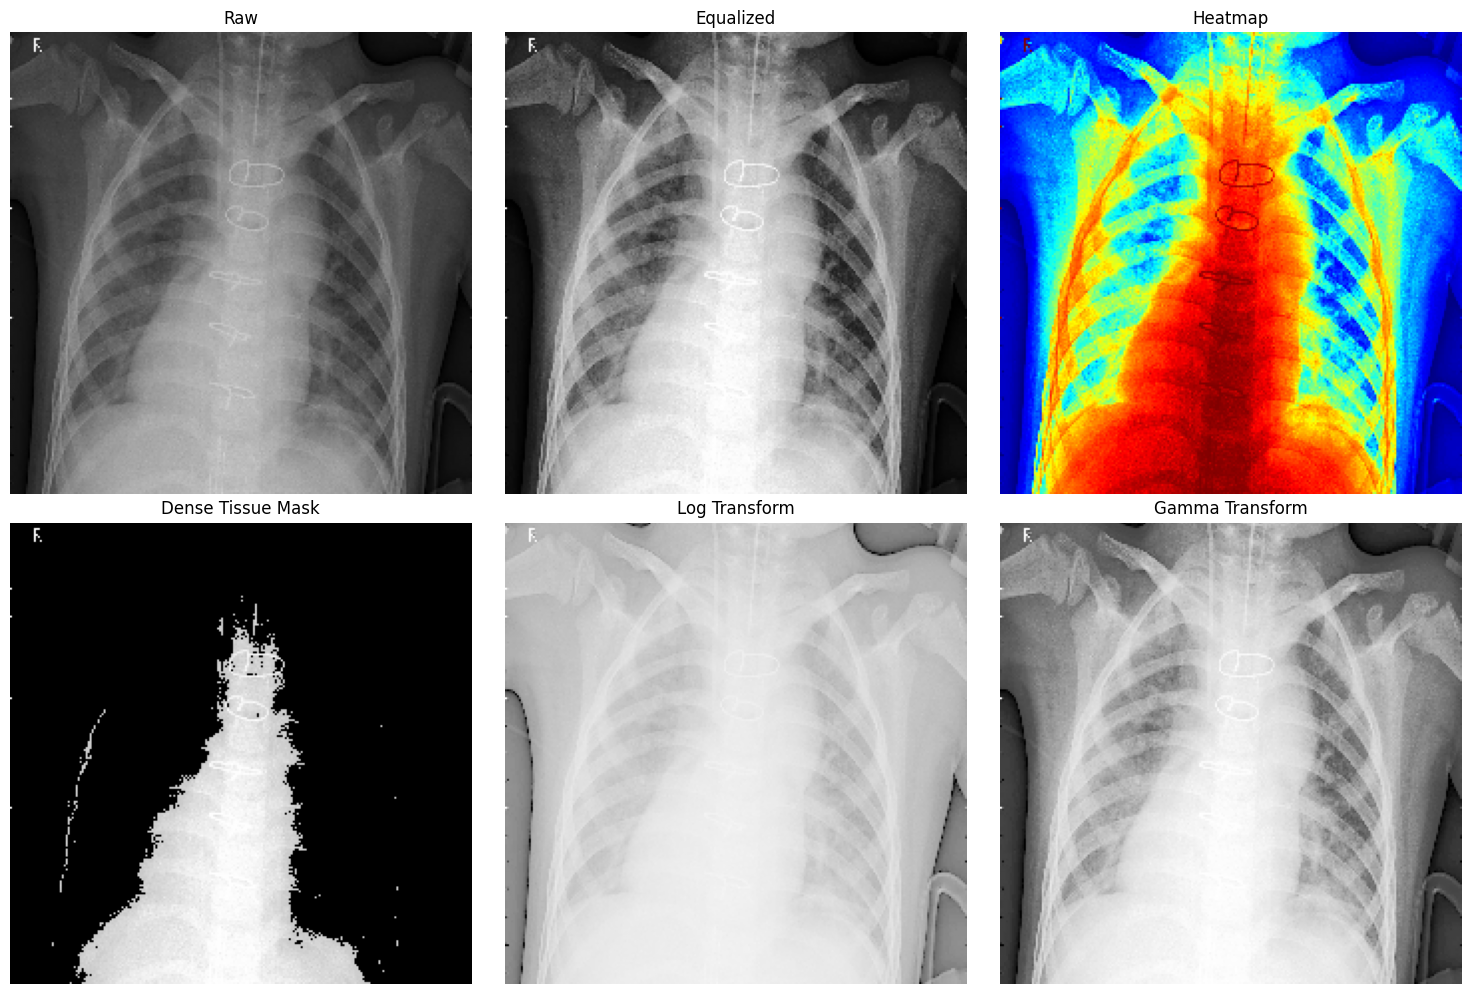

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
imgs = [raw, equalized, cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB),
        dense_tissue_only, log_transformed, gamma_corrected]
titles = ['Raw', 'Equalized', 'Heatmap', 'Dense Tissue Mask', 'Log Transform', 'Gamma Transform']
for a, im, t in zip(ax.ravel(), imgs, titles):
    a.imshow(im, cmap='gray' if im.ndim == 2 else None)
    a.set_title(t)
    a.axis('off')
plt.tight_layout()
plt.savefig('output/08_final_comparison.png', dpi=150)
plt.show()


# Task 2: Multi-Modal Cardiac Image Fusion

**Goal:** Fuse a CT slice (excellent structural boundaries) and its matched
MRI slice (superior soft-tissue detail) of the same heart into a single
unified diagnostic view.

Pipeline: Load pair -> Histogram Equalization (independent) -> Color Mapping
-> Weighted Fusion (`cv2.addWeighted`) -> Log/Gamma safety transforms ->
Comparative Analysis.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)

def show(img, title):
    plt.figure(figsize=(5, 5))
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


## 1. Load Modalities
Load one CT slice and its perfectly corresponding MRI slice.

CT shape: (400, 400) | MRI shape: (400, 400)


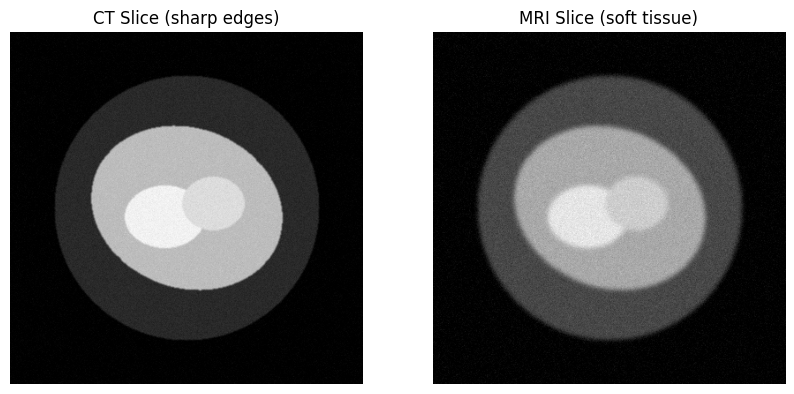

In [2]:
ct = cv2.imread('data/sample_ct.png', cv2.IMREAD_GRAYSCALE)
mri = cv2.imread('data/sample_mri.png', cv2.IMREAD_GRAYSCALE)

assert ct.shape == mri.shape, "CT and MRI slices must be spatially aligned / same shape"
print('CT shape:', ct.shape, '| MRI shape:', mri.shape)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(ct, cmap='gray'); ax[0].set_title('CT Slice (sharp edges)'); ax[0].axis('off')
ax[1].imshow(mri, cmap='gray'); ax[1].set_title('MRI Slice (soft tissue)'); ax[1].axis('off')
plt.show()


## 2. Histogram Equalization
Apply equalization to CT and MRI independently to maximize each modality's
dynamic range before blending.

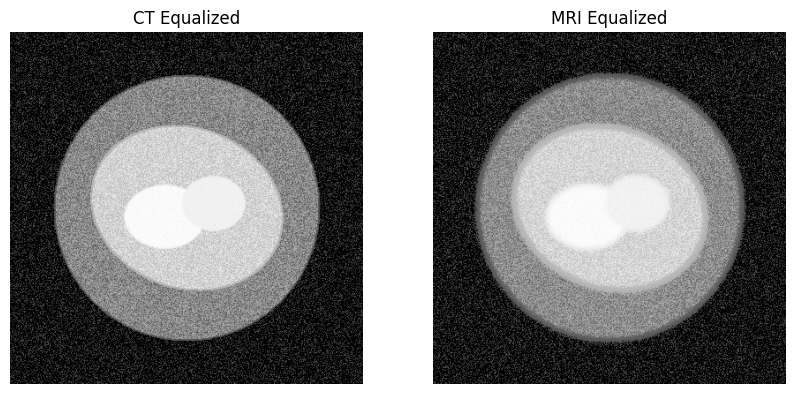

True

In [3]:
ct_eq = cv2.equalizeHist(ct)
mri_eq = cv2.equalizeHist(mri)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(ct_eq, cmap='gray'); ax[0].set_title('CT Equalized'); ax[0].axis('off')
ax[1].imshow(mri_eq, cmap='gray'); ax[1].set_title('MRI Equalized'); ax[1].axis('off')
plt.show()
cv2.imwrite('output/01_ct_equalized.png', ct_eq)
cv2.imwrite('output/01_mri_equalized.png', mri_eq)


## 3. Color Mapping and Fusion (preview overlay)
Convert the enhanced CT and MRI into colored heatmaps using distinct
colormaps so structural (CT) vs soft-tissue (MRI) information stays visually
separable, then overlay them for a first look before weighted fusion.

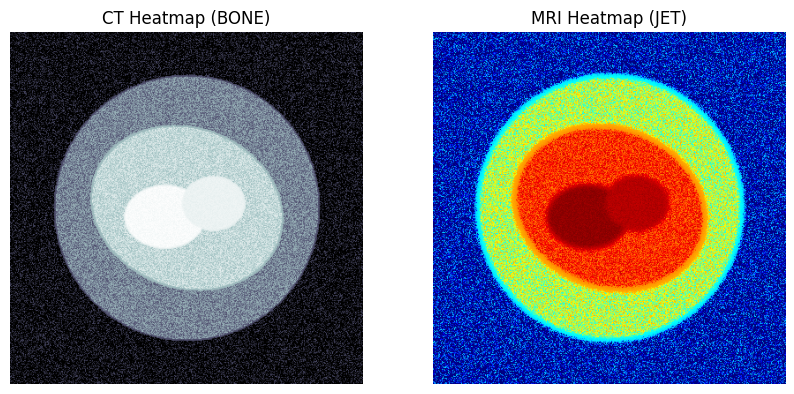

True

In [4]:
ct_color = cv2.applyColorMap(ct_eq, cv2.COLORMAP_BONE)   # structural: bone-like colormap
mri_color = cv2.applyColorMap(mri_eq, cv2.COLORMAP_JET)   # soft tissue: JET highlights variation

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(ct_color, cv2.COLOR_BGR2RGB)); ax[0].set_title('CT Heatmap (BONE)'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(mri_color, cv2.COLOR_BGR2RGB)); ax[1].set_title('MRI Heatmap (JET)'); ax[1].axis('off')
plt.show()
cv2.imwrite('output/02_ct_color.png', ct_color)
cv2.imwrite('output/02_mri_color.png', mri_color)


## 4. Multi-Modal Weighted Fusion
Use `cv2.addWeighted()` to blend the two colored matrices. A heavier weight
(alpha) is assigned to CT to preserve sharp anatomical edges, and a lighter
weight (beta) to MRI to layer in internal tissue variation.

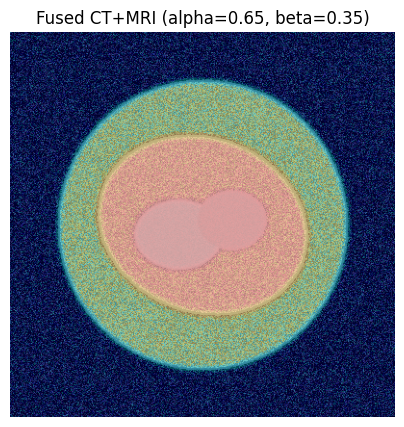

True

In [5]:
ALPHA = 0.65   # CT weight - preserves sharp anatomical boundaries
BETA = 0.35    # MRI weight - adds soft-tissue detail
GAMMA_OFFSET = 0

fused = cv2.addWeighted(ct_color, ALPHA, mri_color, BETA, GAMMA_OFFSET)
show(fused, f'Fused CT+MRI (alpha={ALPHA}, beta={BETA})')
cv2.imwrite('output/03_fused_raw.png', fused)


## 5. Logarithmic and Power-Law Safety Transforms
Pass the fused matrix through log and gamma functions so no critical data
gets crushed into pure black or blown out to pure white during the
weighted-addition step.

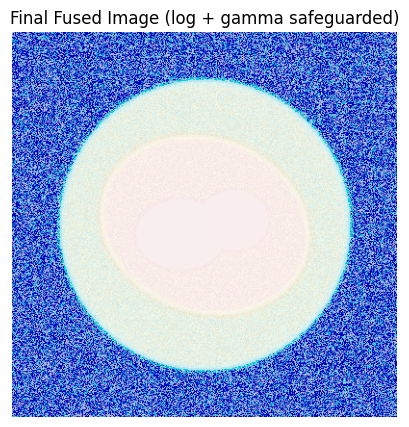

True

In [6]:
fused_f = fused.astype(np.float32)
c = 255 / np.log(1 + fused_f.max())
log_fused = c * np.log(1 + fused_f)
log_fused = np.clip(log_fused, 0, 255).astype(np.uint8)

GAMMA = 0.85
norm = log_fused.astype(np.float32) / 255.0
final_fused = np.power(norm, GAMMA) * 255.0
final_fused = np.clip(final_fused, 0, 255).astype(np.uint8)

show(final_fused, 'Final Fused Image (log + gamma safeguarded)')
cv2.imwrite('output/04_final_fused.png', final_fused)


## 6. Comparative Analysis
Display the standalone CT frame, the standalone MRI frame, and the fused
output side-by-side, plus intensity histograms, to validate the fusion.

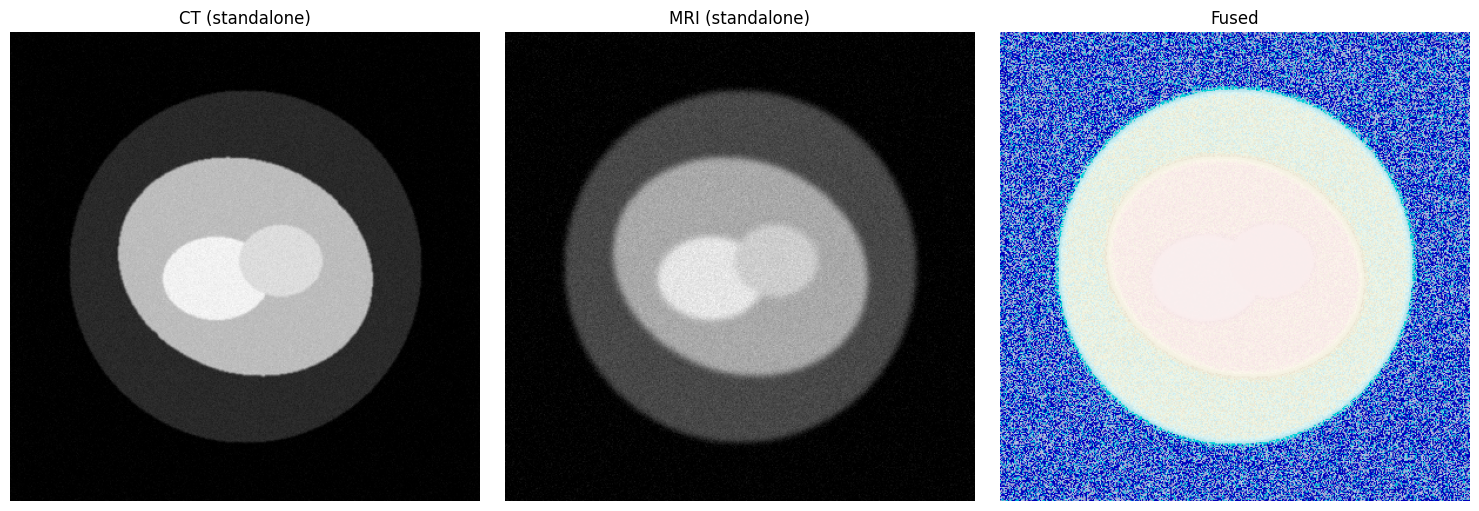

CT std: 72.18 | MRI std: 56.97 | Fused (gray) std: 85.56


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(ct, cmap='gray'); ax[0].set_title('CT (standalone)'); ax[0].axis('off')
ax[1].imshow(mri, cmap='gray'); ax[1].set_title('MRI (standalone)'); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(final_fused, cv2.COLOR_BGR2RGB)); ax[2].set_title('Fused'); ax[2].axis('off')
plt.tight_layout()
plt.savefig('output/05_side_by_side.png', dpi=150)
plt.show()

# Quick quantitative sanity check: fused image should carry the info range of both modalities
print('CT std:', ct.std().round(2), '| MRI std:', mri.std().round(2),
      '| Fused (gray) std:', cv2.cvtColor(final_fused, cv2.COLOR_BGR2GRAY).std().round(2))


# Task 3: Real-Time Echocardiogram Video Analysis

**Goal:** Build a real-time OpenCV pipeline that reads an ultrasound
(.mp4) video frame by frame, applies mathematical enhancements to combat
murky/low-contrast/noisy footage, and displays the corrected feed live
alongside the raw feed.

Pipeline per frame: Histogram Equalization -> Color Mapping (JET) ->
Color Balance -> Log Transform -> Power-Law (Gamma) Transform ->
side-by-side monitoring array.

> **Note on `cv2.imshow` in notebooks/headless environments:** `cv2.imshow()`
> opens a native OS window and requires a display + a running local Python
> process (not a headless server/CI/cloud notebook). The code below is
> written exactly as it should run **locally** (uncomment the `imshow` /
> `waitKey` lines). For this notebook environment (no display attached) we
> additionally save the monitoring array frames to `output/` and compile a
> preview video, so the pipeline can still be verified end-to-end without a
> GUI.


In [1]:
import cv2
import numpy as np
import os

os.makedirs('output', exist_ok=True)
SHOW_WINDOW = False  # set True when running locally with a display attached


## 1. Video Capture Setup
Initialize `cv2.VideoCapture()` to read from the provided ultrasound `.mp4`
file (not a webcam).

In [2]:
VIDEO_PATH = 'data/sample_echo.mp4'
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise IOError(f'Could not open video: {VIDEO_PATH}')

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'FPS: {fps} | Frames: {frame_count} | Size: {width}x{height}')


FPS: 20.0 | Frames: 60 | Size: 400x400


## 2. Per-Frame Enhancement Function
Combines all required mathematical operations into one pipeline step.

In [3]:
def enhance_frame(gray_frame):
    # 1. Histogram Equalization - combat murky ultrasound contrast
    eq = cv2.equalizeHist(gray_frame)

    # 2. Color Mapping - highlight blood flow intensities
    colored = cv2.applyColorMap(eq, cv2.COLORMAP_JET)

    # 3. Color Balance adjustment
    balanced = colored.astype(np.float32)
    for c in range(3):
        mean = balanced[:, :, c].mean()
        balanced[:, :, c] += (128 - mean) * 0.3
    balanced = np.clip(balanced, 0, 255).astype(np.uint8)

    # 4. Logarithmic transformation - reveal darkest heart-chamber regions
    bf = balanced.astype(np.float32)
    c_log = 255 / np.log(1 + bf.max())
    log_img = c_log * np.log(1 + bf)
    log_img = np.clip(log_img, 0, 255).astype(np.uint8)

    # 5. Power-law (gamma) transformation - suppress blinding backscatter noise
    GAMMA = 1.4  # gamma > 1 darkens/suppresses bright noise spikes
    norm = log_img.astype(np.float32) / 255.0
    gamma_img = np.power(norm, GAMMA) * 255.0
    gamma_img = np.clip(gamma_img, 0, 255).astype(np.uint8)

    return gamma_img


## 3. Real-Time Video Processing Loop + Monitoring Array
Extract frames continuously, enhance each one, and concatenate raw + enhanced
side by side. Locally this is displayed live with `cv2.imshow()`; here we
also persist a handful of preview frames and an output video.

In [4]:
out_writer = None
preview_saved = 0
frame_idx = 0
SAVE_EVERY = 10        # save a still every N frames for the README/report
MAX_STILLS = 6

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) if frame.ndim == 3 else frame
    enhanced = enhance_frame(gray)

    raw_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    monitoring_array = np.hstack([raw_bgr, enhanced])

    if out_writer is None:
        h, w = monitoring_array.shape[:2]
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out_writer = cv2.VideoWriter('output/monitoring_array.mp4', fourcc, fps, (w, h))
    out_writer.write(monitoring_array)

    if frame_idx % SAVE_EVERY == 0 and preview_saved < MAX_STILLS:
        cv2.imwrite(f'output/frame_{frame_idx:04d}.png', monitoring_array)
        preview_saved += 1

    # --- Local, GUI-attached execution ---
    if SHOW_WINDOW:
        cv2.imshow('Raw (left) vs Enhanced (right)', monitoring_array)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    frame_idx += 1

cap.release()
if out_writer is not None:
    out_writer.release()
if SHOW_WINDOW:
    cv2.destroyAllWindows()

print(f'Processed {frame_idx} frames. Saved {preview_saved} preview stills and output/monitoring_array.mp4')


Processed 60 frames. Saved 6 preview stills and output/monitoring_array.mp4


## 4. Inspect a Sample Frame from the Monitoring Array

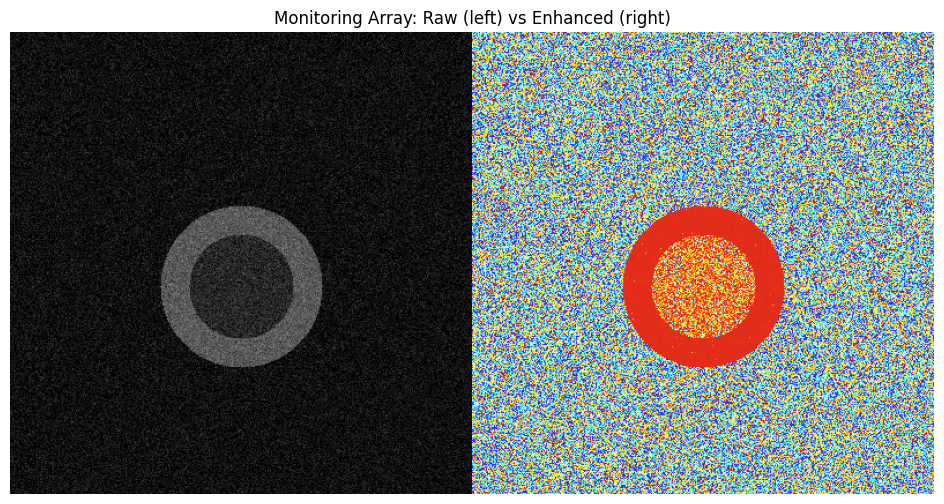

In [5]:
import glob
import matplotlib.pyplot as plt

stills = sorted(glob.glob('output/frame_*.png'))
if stills:
    sample = cv2.imread(stills[len(stills)//2])
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
    plt.title('Monitoring Array: Raw (left) vs Enhanced (right)')
    plt.axis('off')
    plt.show()
else:
    print('No stills saved - check that the video loaded correctly.')


## Running this locally with a live GUI window

```bash
python realtime_echo.py   # or run this notebook with SHOW_WINDOW = True
```

Set `SHOW_WINDOW = True` in the second cell before running on a machine with
a display attached. The loop will pop up a live window titled
*"Raw (left) vs Enhanced (right)"* and update it frame by frame; press `q`
to stop early.
